In [7]:
import pandas as pd
import numpy as np

In [8]:
keep_cols = [
    "Loan_ID",
    "Monthly Reporting Period",
    "Original UPB",
    "Original Interest Rate",
    "Original Loan Term",
    "Interest Bearing UPB",
    "Current Actual UPB",
    "Current Interest Rate",
    "Current Loan Delinquency Status",
    "Loan Age",
    "Zero Balance Code",
    "Amortization Type (Formerly Product Type)"
]

In [9]:
df = pd.read_csv(r"C:\Users\sbalodi\Desktop\final_master_loan_data.csv", usecols=keep_cols)
df = df[(df["Amortization Type (Formerly Product Type)"] == "FRM") & (df["Monthly Reporting Period"] <= 202412)]

C:\Users\sbalodi\AppData\Local\Temp\ipykernel_14316\1248180383.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\sbalodi\Desktop\final_master_loan_data.csv", usecols=keep_cols)


In [10]:
df.tail()

,Loan_ID,Monthly Reporting Period,Current Actual UPB,Current Loan Delinquency Status,Loan Age,Zero Balance Code,Current Interest Rate,Interest Bearing UPB,Original UPB,Original Interest Rate,Amortization Type (Formerly Product Type),Original Loan Term
23248330,F24Q40281883,202412,275000.0,0,1,NaN,6.50,275000.0,275000,6.50,FRM,360
23248334,F24Q40281887,202411,388000.0,0,0,NaN,6.50,388000.0,388000,6.50,FRM,360
23248335,F24Q40281887,202412,387000.0,0,1,NaN,6.50,387000.0,388000,6.50,FRM,360
23248339,F24Q40281890,202411,244000.0,0,0,NaN,6.99,244000.0,244000,6.99,FRM,360
23248340,F24Q40281890,202412,244000.0,0,1,NaN,6.99,244000.0,244000,6.99,FRM,360


# Calculate SMM
### First, calculate Monthly mortgage payment (Included Interest and Principal)

$$ MP = MB_0 \left[ \frac{i(1+i)^n}{(1+i)^n - 1} \right]$$

$MP$ = Monthly mortgage payment  
$MB_0$ = Original mortgage balance  
$i$ = note rate divided by 12  
$n$ = number of months of the mortgage loan

The monthly payment will change when modifying happend  
Case1 : `ZERO BALANCE CODE` is not null  
Case2 : Interest is changed, which means `CURRENT INTEREST RATE` is not equal to `ORIGINAL INTEREST RATE`  

In [11]:
'''
def _level_payment(principal_upb, annual_rate_pct, term_months):
    """
    Fixed-rate level monthly payment (standard mortgage annuity).
    Inputs:
    principal_upb: base principal used for amortization
    annual_rate_pct: annual interest %, e.g., 8.0
    term_months: remaining term in months (integer)
    Returns:
      scheduled monthly payment (float)
    """
    r = (annual_rate_pct / 100.0) / 12.0  # monthly rate in decimal
    n = int(term_months)
    if n <= 0:
        return 0.0
    if r == 0:
        return principal_upb / n
    return principal_upb * (r * (1 + r) ** n) / ((1 + r) ** n - 1)


def find_monthly_payment(i, Original_UPB, Original_Loan_Term,
                         current_interest_rate,
                         original_interest_rate,
                         loan_age,
                         zero_balance_code,
                         balance_of_last_period):
    """
    Return THIS PERIOD's scheduled payment under your two-case logic.
    Case 1: if zero_balance_code is not None -> payment = 0 (loan is closed)
    Case 2: if current_interest_rate != original_interest_rate ->
            recast using the remaining term (N - loan_age) and last period's balance
    Else: use original terms.
    Notes:
      - Parameter i is kept for compatibility but not used.
      - 'balance_of_last_period' should be the period-begin interest-bearing UPB.
    """
    if pd.notna(zero_balance_code):
        return 0.0

    if current_interest_rate != original_interest_rate:
        rem = max(int(Original_Loan_Term) - int(loan_age), 0)
        return _level_payment(balance_of_last_period, current_interest_rate, rem)

    return _level_payment(Original_UPB, original_interest_rate, int(Original_Loan_Term))

def interest_payment(i, p_last):
    """
    Scheduled interest for this period:
    i: current annual interest rate in %
    p_last: period-begin interest-bearing UPB (last period's ending balance)
    """
    r_m = (i / 100.0) / 12.0
    return p_last * r_m

import numpy as np
import pandas as pd

def CPR_SchedPrepay(bal1, bal2, i, Original_UPB, Original_Loan_Term, loan_age, zero_balance_code,
                    original_interest_rate, current_interest_rate):
    """
    Compute Scheduled_Principal and Prepay_Amt only.
    """
    
    if pd.notna(zero_balance_code):
        return 0.0, 0.0

    pay = find_monthly_payment(
        i=i,
        Original_UPB=Original_UPB,
        Original_Loan_Term=Original_Loan_Term,
        current_interest_rate=current_interest_rate,
        original_interest_rate=original_interest_rate,
        loan_age=loan_age,
        zero_balance_code=np.nan,
        balance_of_last_period=bal1
    )

    intr = interest_payment(current_interest_rate, bal1)
    sched_prin = max(min(pay - intr, bal1), 0.0)

    actual_prin = max(bal1 - bal2, 0.0)
    prepay = max(actual_prin - sched_prin, 0.0)

    return sched_prin, prepay


def compute_sched_prin_prepay(df_FRM):
    """
    Expect columns (case-insensitive): 
      Loan Sequence Number, Interest Bearing UPB, Current Actual UPB,
      Current Interest Rate, Loan Age, Zero Balance Code (optional),
      Original UPB, Original Interest Rate, Original Loan Term
    Returns:
      DataFrame with added columns: Bal1, Bal2, Scheduled Prin, Prepay Amt
    """
    df = df_FRM.copy() 
    if "Zero Balance Code" not in df.columns:
        df["Zero Balance Code"] = np.nan

    # Sort within each loan by Loan Age to ensure time order
    df = df.sort_values(["Loan_ID", "Loan Age"]).copy()

    # Beginning-of-period balance (Bal1)
    df["Bal1"] = df.groupby("Loan_ID")["Interest Bearing UPB"].shift(1)
    mask0 = df["Loan Age"] == 0
    df.loc[mask0, "Bal1"] = df.loc[mask0, "Original UPB"]

    # End-of-period balance (Bal2)
    df["Bal2"] = df["Interest Bearing UPB"].astype(float)

    # Merge original term data
    terms = df.groupby("Loan_ID").agg({
        "Original UPB": "first",
        "Original Interest Rate": "first",
        "Original Loan Term": "first"
    }).rename(columns={
        "Original UPB": "F0",
        "Original Interest Rate": "I0",
        "Original Loan Term": "N0"
    })

    df = df.merge(terms, left_on="Loan_ID", right_index=True, how="left")

    # Row-wise compute Scheduled Prin & Prepay Amt
    res = df.apply(
        lambda r: CPR_SchedPrepay(
            bal1=float(r["Bal1"]),
            bal2=float(r["Bal2"]),
            i=float(r["Current Interest Rate"]),
            Original_UPB=float(r["F0"]),
            Original_Loan_Term=int(r["N0"]),
            loan_age=int(r["Loan Age"]),
            zero_balance_code=r["Zero Balance Code"],
            original_interest_rate=float(r["I0"]),
            current_interest_rate=float(r["Current Interest Rate"])
        ),
        axis=1,
        result_type="expand"
    )

    df[["Scheduled Prin", "Prepay Amt"]] = res

    return df
    '''


'\ndef _level_payment(principal_upb, annual_rate_pct, term_months):\n    """\n    Fixed-rate level monthly payment (standard mortgage annuity).\n    Inputs:\n    principal_upb: base principal used for amortization\n    annual_rate_pct: annual interest %, e.g., 8.0\n    term_months: remaining term in months (integer)\n    Returns:\n      scheduled monthly payment (float)\n    """\n    r = (annual_rate_pct / 100.0) / 12.0  # monthly rate in decimal\n    n = int(term_months)\n    if n <= 0:\n        return 0.0\n    if r == 0:\n        return principal_upb / n\n    return principal_upb * (r * (1 + r) ** n) / ((1 + r) ** n - 1)\n\n\ndef find_monthly_payment(i, Original_UPB, Original_Loan_Term,\n                         current_interest_rate,\n                         original_interest_rate,\n                         loan_age,\n                         zero_balance_code,\n                         balance_of_last_period):\n    """\n    Return THIS PERIOD\'s scheduled payment under your two-ca

In [12]:
def compute_sched_prin_prepay_fast(df):
    df = df.copy()

    # Ensure "Zero Balance Code" column exists
    if "Zero Balance Code" not in df.columns:
        df["Zero Balance Code"] = np.nan

    # Sort so shifting is correct
    df = df.sort_values(["Loan_ID", "Loan Age"])

    # --- Extract original loan attributes ---
    df["Orig_UPB"] = df.groupby("Loan_ID")["Original UPB"].transform("first")
    df["Orig_Rate"] = df.groupby("Loan_ID")["Original Interest Rate"].transform("first")
    df["Orig_Term"] = df.groupby("Loan_ID")["Original Loan Term"].transform("first")

    # --- Compute balances ---
    df["Bal1"] = df.groupby("Loan_ID")["Interest Bearing UPB"].shift(1)
    df.loc[df["Loan Age"] == 0, "Bal1"] = df.loc[df["Loan Age"] == 0, "Orig_UPB"]
    df["Bal2"] = df["Interest Bearing UPB"].astype(float)

    # --- Derived values ---
    mrate_curr = (df["Current Interest Rate"].astype(float) / 100) / 12
    mrate_orig = (df["Orig_Rate"].astype(float) / 100) / 12
    rem_term = (df["Orig_Term"].astype(int) - df["Loan Age"].astype(int)).clip(lower=1)

    # --- Level payment formula (vectorized) ---
    def level_payment(principal, mrate, term):
        """Fully vectorized level-payment computation."""
        principal = principal.astype(float)
        mrate = mrate.astype(float)
        term = term.astype(float)

        zero_r = np.isclose(mrate, 0.0)
        pay = np.zeros_like(principal)

        # r = 0 case
        pay[zero_r] = np.divide(principal[zero_r], term[zero_r],
                                where=term[zero_r] > 0, out=np.zeros_like(principal[zero_r]))

        # r != 0 case
        nz = ~zero_r
        r = mrate[nz]
        n = term[nz]
        pay[nz] = principal[nz] * (r * (1 + r) ** n) / ((1 + r) ** n - 1)
        return pay

    # --- Payment logic ---
    same_rate = np.isclose(df["Current Interest Rate"].astype(float), df["Orig_Rate"].astype(float), atol=1e-8)
    pay_orig = level_payment(df["Orig_UPB"].values, mrate_orig.values, df["Orig_Term"].values)
    pay_recast = level_payment(df["Bal1"].fillna(0).values, mrate_curr.values, rem_term.values)
    pay = np.where(same_rate, pay_orig, pay_recast)

    # --- If liquidated, no scheduled payment this period ---
    liq_mask = df["Zero Balance Code"].notna().values
    pay[liq_mask] = 0.0

    # --- Scheduled interest & principal ---
    intr = mrate_curr.values * df["Bal1"].fillna(0).values
    sched_prin = np.clip(pay - intr, 0, None)
    sched_prin = np.minimum(sched_prin, df["Bal1"].fillna(0).values)

    # --- Actual principal change ---
    actual_prin = np.clip(df["Bal1"].fillna(0).values - df["Bal2"].values, 0, None)

    # --- Prepayment logic ---
    prepay = np.clip(actual_prin - sched_prin, 0, None)

    # If Zero Balance Code == '01', count full payoff as prepay
    zb = df["Zero Balance Code"].astype(str).values
    is_prepay = (zb == "01")
    prepay[is_prepay] = df["Bal1"].fillna(0).values[is_prepay]

    # --- Assign results back to df ---
    df["Scheduled Prin"] = sched_prin
    df["Prepay Amt"] = prepay
    df["Interest Sched"] = intr
    df["Payment"] = pay

    return df


In [13]:
# Lean dtypes = big speed/memory win
num_casts = {
    "Loan Age": "int32",
    "Original Loan Term": "int32",
    "Original UPB": "float32",
    "Original Interest Rate": "float32",
    "Current Interest Rate": "float32",
    "Interest Bearing UPB": "float32",
}
for c,t in num_casts.items():
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype(t)

for c in ["Loan_ID", "Zero Balance Code"]:
    if c in df.columns:
        df[c] = df[c].astype("category")

# Sort once; mergesort is stable (important for shifts)
df = df.sort_values(["Loan_ID", "Loan Age"], kind="mergesort")


In [14]:
results = []
for m, chunk in df.groupby("Monthly Reporting Period", sort=True):
    out = compute_sched_prin_prepay_fast(chunk)
    results.append(out)

df_final = pd.concat(results, ignore_index=True)


C:\Users\sbalodi\AppData\Local\Temp\ipykernel_14316\2184372563.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["Orig_UPB"] = df.groupby("Loan_ID")["Original UPB"].transform("first")
C:\Users\sbalodi\AppData\Local\Temp\ipykernel_14316\2184372563.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["Orig_Rate"] = df.groupby("Loan_ID")["Original Interest Rate"].transform("first")
C:\Users\sbalodi\AppData\Local\Temp\ipykernel_14316\2184372563.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current

In [15]:
df_final.head()

,Loan_ID,Monthly Reporting Period,Current Actual UPB,Current Loan Delinquency Status,Loan Age,Zero Balance Code,Current Interest Rate,Interest Bearing UPB,Original UPB,Original Interest Rate,...,Original Loan Term,Orig_UPB,Orig_Rate,Orig_Term,Bal1,Bal2,Scheduled Prin,Prepay Amt,Interest Sched,Payment
0,F14Q10000011,201402,62000.0,0,0,NaN,4.250,62000.0,62000.0,4.250,...,180,62000.0,4.250,180.0,62000.0,62000.0,246.829282,0.0,219.583333,466.412615
1,F14Q10000037,201402,247000.0,0,0,NaN,4.750,247000.0,247000.0,4.750,...,240,247000.0,4.750,240.0,247000.0,247000.0,618.464027,0.0,977.708333,1596.172361
2,F14Q10000123,201402,170000.0,0,0,NaN,4.125,170000.0,170000.0,4.125,...,360,170000.0,4.125,360.0,170000.0,170000.0,239.529545,0.0,584.375000,823.904545
3,F14Q10000138,201402,50000.0,0,0,NaN,3.375,50000.0,50000.0,3.375,...,180,50000.0,3.375,180.0,50000.0,50000.0,213.754928,0.0,140.625000,354.379928
4,F14Q10000168,201402,114000.0,0,0,NaN,3.500,114000.0,114000.0,3.500,...,180,114000.0,3.500,180.0,114000.0,114000.0,482.466097,0.0,332.500000,814.966097


In [16]:
# ---- Configuration ----
COL_DT = "Monthly Reporting Period"   # change if your date column has another name

# ---- Ensure we have a datetime month key ----
if np.issubdtype(df_final[COL_DT].dtype, np.number):
    # e.g. 201401 → 2014-01
    df_final["_Month"] = pd.to_datetime(df_final[COL_DT].astype(int).astype(str), format="%Y%m")
else:
    df_final["_Month"] = pd.to_datetime(df_final[COL_DT], errors="coerce")

df_final["_Month"] = df_final["_Month"].dt.to_period("M").dt.to_timestamp()

# ---- Aggregate to monthly cashflows ----
monthly = (
    df_final.groupby("_Month")
    .agg(
        Beg_Bal=("Bal1", "sum"),
        Scheduled_Principal=("Scheduled Prin", "sum"),
        Prepay=("Prepay Amt", "sum"),
    )
    .reset_index()
)

# ---- Compute SMM & CPR ----
den = monthly["Beg_Bal"] - monthly["Scheduled_Principal"]
monthly["SMM"] = np.where(den > 0, monthly["Prepay"] / den, 0.0)
monthly["CPR"] = 1 - (1 - monthly["SMM"]) ** 12

# ---- Add total cashflow columns (optional) ----
monthly["Total_Principal"] = monthly["Scheduled_Principal"] + monthly["Prepay"]
monthly["Total_Cashflow"] = monthly["Total_Principal"]  # add interest later if needed

# ---- Sort & show ----
monthly = monthly.rename(columns={"_Month": "Month"}).sort_values("Month")

print(monthly[["Month", "Beg_Bal", "Scheduled_Principal", "Prepay", "SMM", "CPR"]].head(12))


        Month      Beg_Bal  Scheduled_Principal        Prepay       SMM  \
0  2014-02-01  643614976.0         1.217542e+06  4.969283e+05  0.000774   
1  2014-03-01  632003968.0         1.134198e+06  5.577706e+05  0.000884   
2  2014-04-01  899582016.0         1.645703e+06  9.516524e+05  0.001060   
3  2014-05-01  667212992.0         1.179535e+06  1.099847e+06  0.001651   
4  2014-06-01  697787008.0         1.245583e+06  2.425549e+05  0.000348   
5  2014-07-01  842628992.0         1.496535e+06  3.214622e+05  0.000382   
6  2014-08-01  747582016.0         1.372378e+06  9.954285e+05  0.001334   
7  2014-09-01  756636992.0         1.399973e+06  1.109528e+06  0.001469   
8  2014-10-01  724172032.0         1.312812e+06  1.128467e+06  0.001561   
9  2014-11-01  727241984.0         1.320491e+06  7.460948e+05  0.001028   
10 2014-12-01  749777024.0         1.439163e+06  1.250530e+06  0.001671   
11 2015-01-01  764017024.0         1.471659e+06  7.471856e+05  0.000980   

         CPR  
0   0.009

In [17]:
print(monthly.columns)

Index(['Month', 'Beg_Bal', 'Scheduled_Principal', 'Prepay', 'SMM', 'CPR',
       'Total_Principal', 'Total_Cashflow'],
      dtype='object')


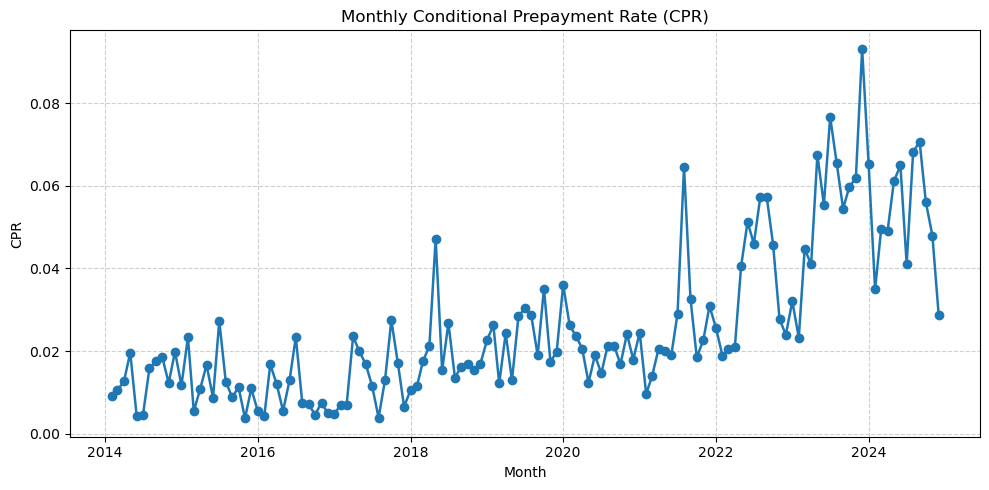

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(monthly["Month"], monthly["CPR"], marker="o", linewidth=1.8)
plt.title("Monthly Conditional Prepayment Rate (CPR)")
plt.xlabel("Month")
plt.ylabel("CPR")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [19]:
# Add month index 1, 2, 3, ...
monthly["t"] = np.arange(1, len(monthly) + 1)

# Compute 100% PSA benchmark CPR for each month
monthly["CPR_100PSA"] = monthly["t"].apply(lambda x: 0.002*x if x < 30 else 0.06)

# Compute best-fit multiplier k
k = (monthly["CPR"] * monthly["CPR_100PSA"]).sum() / (monthly["CPR_100PSA"]**2).sum()

PSA_equivalent = 100 * k
print(f"Equivalent PSA speed: {PSA_equivalent:.1f}%")


Equivalent PSA speed: 47.8%
